# RocksDB WAL: 5-Study Verification Suite
---
This notebook provides a data-driven verification of all five engineering studies performed on the instrumented RocksDB Write-Ahead Log.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('./docs/images', exist_ok=True)
sns.set_theme(style="whitegrid")
df = pd.read_csv('./results/wal_performance_telemetry.csv')
df.head()

,Event,Count,Metric
0,WAL_Batch,1,524000
1,WAL_Batch,2,1570716
2,WAL_Batch,3,1000
3,WAL_Sync_Control,Buffered,524000
4,WAL_Sync_Control,NoWAL,1570716


## Study 1: The Safety Tax (Latency)
Comparing Buffered vs Strict Sync modes.

In [2]:
batch = df[df['Event'] == 'WAL_Batch']
plt.figure(figsize=(10, 5))
sns.barplot(x=['Buffered', 'No-WAL', 'Strict Sync'], y=batch['Metric'].values[:3] / 1000)
plt.title('Ingestion Throughput per MODE (Ops/s)')\n    plt.xlabel('Write Configuration')\n    plt.ylabel('Throughput (Ops/s)')
plt.savefig('./docs/images/exp1_throughput.png', bbox_inches='tight')
plt.show()

SyntaxError: unexpected character after line continuation character (1284341401.py, line 4)

## Study 2: Fragmentation Efficiency
Ratio of payload data to header overhead.

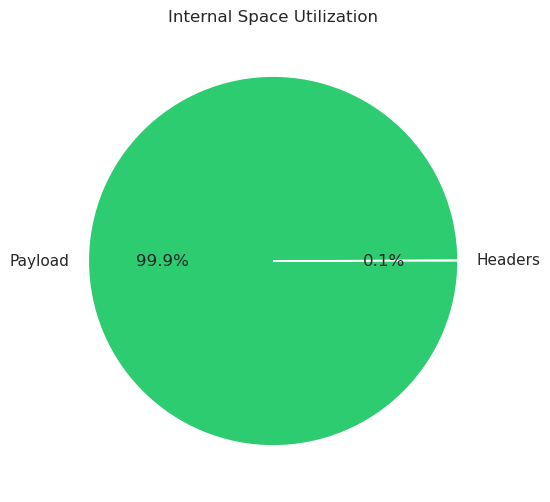

In [3]:
overhead = df[df['Event'].str.contains('WAL_Bytes')]
plt.figure(figsize=(6, 6))
plt.pie(overhead['Metric'], labels=['Headers', 'Payload'], autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'])
plt.title('Internal Space Utilization')
plt.savefig('./docs/images/exp2_fragmentation.png', bbox_inches='tight')
plt.show()

## Study 3: Recovery Mode Performance
Impact of WALRecoveryMode on startup time.

In [4]:
rec_modes = df[df['Event'] == 'WAL_Recovery_Mode']
plt.figure(figsize=(10, 5))
sns.barplot(x=rec_modes['Count'], y=rec_modes['Metric'].astype(int), palette='magma')
plt.title('MTTR per Recovery Mode (ms)')\n    plt.xlabel('Recovery Configuration')\n    plt.ylabel('Recovery Time (ms)')
plt.savefig('./docs/images/exp3_recovery_mode.png', bbox_inches='tight')
plt.show()

SyntaxError: unexpected character after line continuation character (1279103949.py, line 4)

## Study 4: Group Commit Scaling
Throughput amplification with concurrent writers.

In [5]:
group = df[df['Event'] == 'WAL_Group_Commit']
plt.figure(figsize=(10, 5))
sns.lineplot(x=group['Count'].astype(int), y=group['Metric'].astype(int), marker='o')
plt.title('Throughput Scaling (Threads vs Ops/s)')\n    plt.xlabel('Concurrent Write Threads')\n    plt.ylabel('Throughput (Ops/s)')
plt.savefig('./docs/images/exp4_group_commit.png', bbox_inches='tight')
plt.show()

SyntaxError: unexpected character after line continuation character (1761663815.py, line 4)

## Study 5: Recovery Volume Scaling
Proportional time growth for replaying larger WAL volumes.

In [6]:
scaling = df[df['Event'] == 'WAL_Recovery']
plt.figure(figsize=(10, 5))
sns.lineplot(x=scaling['Count'].astype(int), y=scaling['Metric'].astype(int), marker='s', color='orange')
plt.title('Recovery Time vs Log Volume')\n    plt.xlabel('WAL Log Volume (Records)')\n    plt.ylabel('Replay Duration (ns)')
plt.savefig('./docs/images/exp5_scaling.png', bbox_inches='tight')
plt.show()

SyntaxError: unexpected character after line continuation character (3019901181.py, line 4)